# Notebook 08b — LightGBM: Weather Effects on Cycling Demand


Fits **LightGBM (Poisson objective)** with **SHAP** for interpretation.

Sections 0–0c and the train/test split are identical to notebook 08.


## 0. Imports & Setup

In [126]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm", "shap"])


0

In [127]:
import pickle
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")
_want = ["site ID", "site_type"]
if "commute_score" in site_cls.columns:
    _want.append("commute_score")
site_cls = site_cls[_want]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  →  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())


Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
mixed       48735
commuter    47956
leisure     47647


## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Identical to notebook 08.


In [128]:
# ── outlier blacklist (informed by IQR audit above) ───────────────────
remove_dates = [
    (105, '2023-03-03'),
    (85,  '2024-07-25'),
    (20,  '2024-06-02'),
    (140, '2024-07-13'),
    (129, '2024-08-12'),
    (78,  '2023-07-01'),
    (50,  '2024-09-18'),
    (94,  '2023-08-20'),
    (33,  '2023-01-20'),
    (81,  '2024-08-18'),
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

event_dates = [
    (70,  '2023-09-16'), (70,  '2024-09-21'),
    (85,  '2024-07-07'), (85,  '2024-07-21'),
    (72,  '2024-05-08'), (51,  '2024-05-08'),
    (43,  '2023-05-28'), (44,  '2023-05-28'),
    (28,  '2024-04-06'), (28,  '2024-04-13'), (28,  '2024-04-14'),
    (28,  '2023-04-30'), (28,  '2023-05-01'), (28,  '2023-05-04'),
    (34,  '2024-04-06'), (34,  '2023-04-30'), (34,  '2023-06-03'),
    (14,  '2023-09-24'), (14,  '2024-09-22'),
    (48,  '2024-09-18'), (48,  '2024-09-19'), (48,  '2024-09-20'),
    (48,  '2024-09-21'), (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

# ── train / test split ─────────────────────────────────────────────────
train = panel_good[panel_good["date"].dt.year == 2023].copy()
val   = panel_good[panel_good["date"].dt.year == 2024].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

print(f"\nTrain size : {len(train):,} rows (2023)")
print(f"Val size   : {len(val):,} rows (2024)")
print(f"Test size  : {len(test):,} rows (2025)")


Removed 26 extreme outlier rows
Flagged 24 recurring event days

Train size : 47,836 rows (2023)
Val size   : 48,351 rows (2024)
Test size  : 48,151 rows (2025)


## 1. Feature Engineering

In [129]:
# Encode boolean features as integers
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col]      = train[col].astype(int)
    val[col]        = val[col].astype(int)
    test[col]       = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

# LightGBM uses site_idx as a categorical feature (instead of GAM's site_offset)
le_site = LabelEncoder()
train["site_idx"]      = le_site.fit_transform(train["site ID"])
val["site_idx"]        = le_site.transform(val["site ID"])
test["site_idx"]       = le_site.transform(test["site ID"])
panel_good["site_idx"] = le_site.transform(panel_good["site ID"])

# Same weather + calendar features as GAM notebook 08, plus site_idx
ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
    "site_idx",
]

# Categorical features (by name — must match ALL_FEATURES exactly)
CAT_FEATURES = [
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
    "site_idx",
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Categorical : {CAT_FEATURES}")
print(f"Train shape: {train.shape}  |  Val shape: {val.shape}  |  Test shape: {test.shape}")


Features (15): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'site_idx']
Categorical : ['dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'site_idx']
Train shape: (47836, 58)  |  Val shape: (48351, 58)  |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

LightGBM predicts count directly (Poisson objective) — no log-transform or site offset needed.


In [130]:
def make_X_y(df, features):
    cols = features + ["aantal"]
    df_clean = df[cols].dropna().copy()
    for col in CAT_FEATURES:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype("int32")
    X = df_clean[features]
    y = df_clean["aantal"].astype(float).values
    return X, y, df_clean.index

X_train, y_train, train_idx = make_X_y(train, ALL_FEATURES)
X_val,   y_val,   val_idx   = make_X_y(val,   ALL_FEATURES)
X_test,  y_test,  test_idx  = make_X_y(test,  ALL_FEATURES)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"y_train — mean: {y_train.mean():.1f}, std: {y_train.std():.1f}, "
      f"min: {y_train.min():.0f}, max: {y_train.max():.0f}")

dispersion = y_train.var() / y_train.mean()
print(f"\nDispersion ratio (var/mean) = {dispersion:.1f}  "
      f"{'— overdispersed, Poisson still OK for LightGBM' if dispersion > 3 else '— Poisson OK'}")


X_train : (47709, 15)  |  y_train : (47709,)
X_val   : (48329, 15)    |  y_val   : (48329,)
X_test  : (48151, 15)   |  y_test  : (48151,)
y_train — mean: 476.8, std: 628.7, min: 0, max: 9984

Dispersion ratio (var/mean) = 829.0  — overdispersed, Poisson still OK for LightGBM


## 3. LightGBM Hyperparameters & Training Utilities

In [131]:
LGB_PARAMS = dict(
    objective              = "poisson",
    metric                 = "poisson",
    poisson_max_delta_step = 0.7,
    num_leaves             = 31,
    max_depth              = 6,
    learning_rate          = 0.05,
    feature_fraction       = 0.8,
    bagging_fraction       = 0.8,
    bagging_freq           = 5,
    min_child_samples      = 50,
    reg_alpha              = 0.05,
    reg_lambda             = 2.0,
    verbose                = -1,
    n_jobs                 = -1,
    random_state           = 42,
)
NUM_BOOST_ROUND = 2000

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

def train_lgb(X_tr, y_tr, X_val, y_val, feature_names, cat_features):
    """Train with early stopping on a held-out validation split to find best_iteration."""
    dtrain = lgb.Dataset(X_tr, label=y_tr,
                         feature_name=feature_names,
                         categorical_feature=cat_features)
    dval   = lgb.Dataset(X_val, label=y_val,
                         feature_name=feature_names,
                         categorical_feature=cat_features,
                         reference=dtrain)
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ]
    model = lgb.train(LGB_PARAMS, dtrain,
                      num_boost_round=NUM_BOOST_ROUND,
                      valid_sets=[dval], callbacks=callbacks)
    print(f"    Best iteration: {model.best_iteration}")
    return model

def train_lgb_final(X_tr, y_tr, n_estimators, feature_names, cat_features):
    """Retrain on combined train+val data with fixed iterations (no early stopping)."""
    dtrain = lgb.Dataset(X_tr, label=y_tr,
                         feature_name=feature_names,
                         categorical_feature=cat_features)
    model = lgb.train(LGB_PARAMS, dtrain,
                      num_boost_round=n_estimators,
                      callbacks=[lgb.log_evaluation(period=100)])
    print(f"    Final model: {n_estimators} iterations on {len(y_tr):,} rows")
    return model

# Use 2024 as the validation set for early stopping
print(f"Train (2023): {len(X_train):,}  Val (2024): {len(X_val):,}")


Train (2023): 47,709  Val (2024): 48,329


## 4. Model A — Full LightGBM (all stations)

In [132]:
# Step 1: train on 2023 / validate on 2024 → find best_iteration + true val performance
print("Step 1 — Fitting full LightGBM (2023 train / 2024 val)...")
lgb_full_tmp   = train_lgb(X_train, y_train, X_val, y_val, ALL_FEATURES, CAT_FEATURES)
best_iter_full = lgb_full_tmp.best_iteration

# True out-of-sample validation: tmp model has never seen 2024
y_pred_train_tmp = lgb_full_tmp.predict(X_train)
y_pred_val_tmp   = lgb_full_tmp.predict(X_val)

print("\n" + "=" * 52)
print("MODEL A — Full LightGBM: Validation Performance (tmp)")
print("=" * 52)
evaluate(y_train, y_pred_train_tmp, "Train 2023")
val_mae, val_rmse, val_r2 = evaluate(y_val, y_pred_val_tmp, "Val   2024")
print("=" * 52)

# Step 2: retrain on 2023+2024 with fixed iterations (final model)
print("\nStep 2 — Retraining full LightGBM on 2023+2024...")
X_trainval = pd.concat([X_train, X_val])
y_trainval  = np.concatenate([y_train, y_val])
lgb_full = train_lgb_final(X_trainval, y_trainval, best_iter_full, ALL_FEATURES, CAT_FEATURES)

y_pred_test_full = lgb_full.predict(X_test)

print("\n" + "=" * 52)
print("MODEL A — Full LightGBM: Test Performance (final)")
print("=" * 52)
test_mae, test_rmse, test_r2 = evaluate(y_test, y_pred_test_full, "Test  2025")
print("=" * 52)

fi = pd.Series(lgb_full.feature_importance(importance_type="gain"),
               index=ALL_FEATURES).sort_values(ascending=False)
print("\nTop-10 features by gain:")
print(fi.head(10).round(0).to_string())


Step 1 — Fitting full LightGBM (2023 train / 2024 val)...
[100]	valid_0's poisson: -2746.52
[200]	valid_0's poisson: -2756.57
[300]	valid_0's poisson: -2760.62
[400]	valid_0's poisson: -2762.32
[500]	valid_0's poisson: -2763.07
[600]	valid_0's poisson: -2763.39
[700]	valid_0's poisson: -2763.53
[800]	valid_0's poisson: -2763.67
[900]	valid_0's poisson: -2763.75
    Best iteration: 915

MODEL A — Full LightGBM: Validation Performance (tmp)
  Train 2023  : MAE=47.0  RMSE=97.4  R²=0.976
  Val   2024  : MAE=95.7  RMSE=221.6  R²=0.879

Step 2 — Retraining full LightGBM on 2023+2024...
    Final model: 915 iterations on 96,038 rows

MODEL A — Full LightGBM: Test Performance (final)
  Test  2025  : MAE=110.8  RMSE=259.4  R²=0.866

Top-10 features by gain:
site_idx             311208350.0
month                 16684872.0
is_weekend            11200716.0
sunshine_min          10774430.0
precip_total           7731783.0
temp_avg               6793230.0
dayofweek              4117833.0
is_school_

## 5. Model B — Commuter LightGBM

In [133]:
train_c = train[train["site_type"] == "commuter"].copy()
val_c   = val[val["site_type"]     == "commuter"].copy()
test_c  = test[test["site_type"]   == "commuter"].copy()

# Separate LabelEncoder for commuter sites only
le_c = LabelEncoder()
train_c["site_idx"] = le_c.fit_transform(train_c["site ID"])
val_c["site_idx"]   = le_c.transform(val_c["site ID"])
test_c["site_idx"]  = le_c.transform(test_c["site ID"])

X_train_c, y_train_c, _ = make_X_y(train_c, ALL_FEATURES)
X_val_c,   y_val_c,   _ = make_X_y(val_c,   ALL_FEATURES)
X_test_c,  y_test_c,  _ = make_X_y(test_c,  ALL_FEATURES)

# Step 1: early stopping + true validation
print("Step 1 — Fitting commuter LightGBM (2023 train / 2024 val)...")
lgb_commuter_tmp = train_lgb(X_train_c, y_train_c, X_val_c, y_val_c, ALL_FEATURES, CAT_FEATURES)
best_iter_c = lgb_commuter_tmp.best_iteration

print("\n" + "=" * 52)
print("MODEL B — Commuter LightGBM: Validation Performance (tmp)")
print("=" * 52)
evaluate(y_train_c, lgb_commuter_tmp.predict(X_train_c), "Train 2023")
evaluate(y_val_c,   lgb_commuter_tmp.predict(X_val_c),   "Val   2024")
print("=" * 52)

# Step 2: retrain on 2023+2024
print("\nStep 2 — Retraining commuter LightGBM on 2023+2024...")
X_trainval_c = pd.concat([X_train_c, X_val_c])
y_trainval_c  = np.concatenate([y_train_c, y_val_c])
lgb_commuter = train_lgb_final(X_trainval_c, y_trainval_c, best_iter_c, ALL_FEATURES, CAT_FEATURES)

y_pred_c = lgb_commuter.predict(X_test_c)
print("\nCommuter LightGBM: Test Performance (final)")
mae_c, rmse_c, r2_c = evaluate(y_test_c, y_pred_c, "Test  2025")


Step 1 — Fitting commuter LightGBM (2023 train / 2024 val)...
[100]	valid_0's poisson: -2584.88
[200]	valid_0's poisson: -2591.21
[300]	valid_0's poisson: -2591.95
[400]	valid_0's poisson: -2592.35
[500]	valid_0's poisson: -2592.56
[600]	valid_0's poisson: -2592.75
[700]	valid_0's poisson: -2592.89
[800]	valid_0's poisson: -2592.99
[900]	valid_0's poisson: -2593.12
    Best iteration: 924

MODEL B — Commuter LightGBM: Validation Performance (tmp)
  Train 2023  : MAE=32.3  RMSE=53.2  R²=0.988
  Val   2024  : MAE=81.0  RMSE=153.3  R²=0.901

Step 2 — Retraining commuter LightGBM on 2023+2024...
    Final model: 924 iterations on 31,955 rows

Commuter LightGBM: Test Performance (final)
  Test  2025  : MAE=104.3  RMSE=231.5  R²=0.819


## 6. Model C — Leisure LightGBM

In [134]:
train_l = train[train["site_type"] == "leisure"].copy()
val_l   = val[val["site_type"]     == "leisure"].copy()
test_l  = test[test["site_type"]   == "leisure"].copy()

le_l = LabelEncoder()
train_l["site_idx"] = le_l.fit_transform(train_l["site ID"])
val_l["site_idx"]   = le_l.transform(val_l["site ID"])
test_l["site_idx"]  = le_l.transform(test_l["site ID"])

X_train_l, y_train_l, _ = make_X_y(train_l, ALL_FEATURES)
X_val_l,   y_val_l,   _ = make_X_y(val_l,   ALL_FEATURES)
X_test_l,  y_test_l,  _ = make_X_y(test_l,  ALL_FEATURES)

# Step 1: early stopping + true validation
print("Step 1 — Fitting leisure LightGBM (2023 train / 2024 val)...")
lgb_leisure_tmp = train_lgb(X_train_l, y_train_l, X_val_l, y_val_l, ALL_FEATURES, CAT_FEATURES)
best_iter_l = lgb_leisure_tmp.best_iteration

print("\n" + "=" * 52)
print("MODEL C — Leisure LightGBM: Validation Performance (tmp)")
print("=" * 52)
evaluate(y_train_l, lgb_leisure_tmp.predict(X_train_l), "Train 2023")
evaluate(y_val_l,   lgb_leisure_tmp.predict(X_val_l),   "Val   2024")
print("=" * 52)

# Step 2: retrain on 2023+2024
print("\nStep 2 — Retraining leisure LightGBM on 2023+2024...")
X_trainval_l = pd.concat([X_train_l, X_val_l])
y_trainval_l  = np.concatenate([y_train_l, y_val_l])
lgb_leisure = train_lgb_final(X_trainval_l, y_trainval_l, best_iter_l, ALL_FEATURES, CAT_FEATURES)

y_pred_l = lgb_leisure.predict(X_test_l)
print("\nLeisure LightGBM: Test Performance (final)")
mae_l, rmse_l, r2_l = evaluate(y_test_l, y_pred_l, "Test  2025")

print("\n" + "=" * 58)
print("MODEL COMPARISON — Test 2025 (final models)")
print("=" * 58)
print(f"{'Metric':<6} | {'Full LGBM':>10} | {'Commuter LGBM':>13} | {'Leisure LGBM':>12}")
print("-" * 58)
print(f"{'MAE':<6} | {test_mae:>10.1f} | {mae_c:>13.1f} | {mae_l:>12.1f}")
print(f"{'RMSE':<6} | {test_rmse:>10.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f}")
print(f"{'R²':<6} | {test_r2:>10.3f} | {r2_c:>13.3f} | {r2_l:>12.3f}")
print("=" * 58)


Step 1 — Fitting leisure LightGBM (2023 train / 2024 val)...
[100]	valid_0's poisson: -2662.83
[200]	valid_0's poisson: -2670.43
[300]	valid_0's poisson: -2672.78
[400]	valid_0's poisson: -2673.46
[500]	valid_0's poisson: -2673.98
[600]	valid_0's poisson: -2674.2
[700]	valid_0's poisson: -2674.19
    Best iteration: 655

MODEL C — Leisure LightGBM: Validation Performance (tmp)
  Train 2023  : MAE=47.8  RMSE=95.9  R²=0.978
  Val   2024  : MAE=105.9  RMSE=260.0  R²=0.833

Step 2 — Retraining leisure LightGBM on 2023+2024...
    Final model: 655 iterations on 31,646 rows

Leisure LightGBM: Test Performance (final)
  Test  2025  : MAE=125.2  RMSE=299.3  R²=0.787

MODEL COMPARISON — Test 2025 (final models)
Metric |  Full LGBM | Commuter LGBM | Leisure LGBM
----------------------------------------------------------
MAE    |      110.8 |         104.3 |        125.2
RMSE   |      259.4 |         231.5 |        299.3
R²     |      0.866 |         0.819 |        0.787


## 7. SHAP Partial Dependence Plots

**SHAP vs GAM partial dependence**: LightGBM uses Poisson objective so it predicts
`log(E[count])` internally. SHAP values are additive on this log scale — directly
comparable to GAM's `partial_dependence()` output.




In [135]:
np.random.seed(42)
N_SHAP = 3000

idx_c_s = np.random.choice(len(X_test_c), min(N_SHAP, len(X_test_c)), replace=False)
idx_l_s = np.random.choice(len(X_test_l), min(N_SHAP, len(X_test_l)), replace=False)

explainer_c = shap.TreeExplainer(lgb_commuter)
explainer_l = shap.TreeExplainer(lgb_leisure)

print("Computing SHAP values for commuter model...")
shap_c = explainer_c.shap_values(X_test_c.iloc[idx_c_s])
print("Computing SHAP values for leisure model...")
shap_l = explainer_l.shap_values(X_test_l.iloc[idx_l_s])

# Additivity check
_chk = np.abs(
    np.log(lgb_commuter.predict(X_test_c.iloc[idx_c_s[:5]])) -
    (shap_c[:5].sum(axis=1) + explainer_c.expected_value)
).mean()
print(f"SHAP additivity error (should be ~0): {_chk:.4f}")


Computing SHAP values for commuter model...
Computing SHAP values for leisure model...
SHAP additivity error (should be ~0): 0.0000


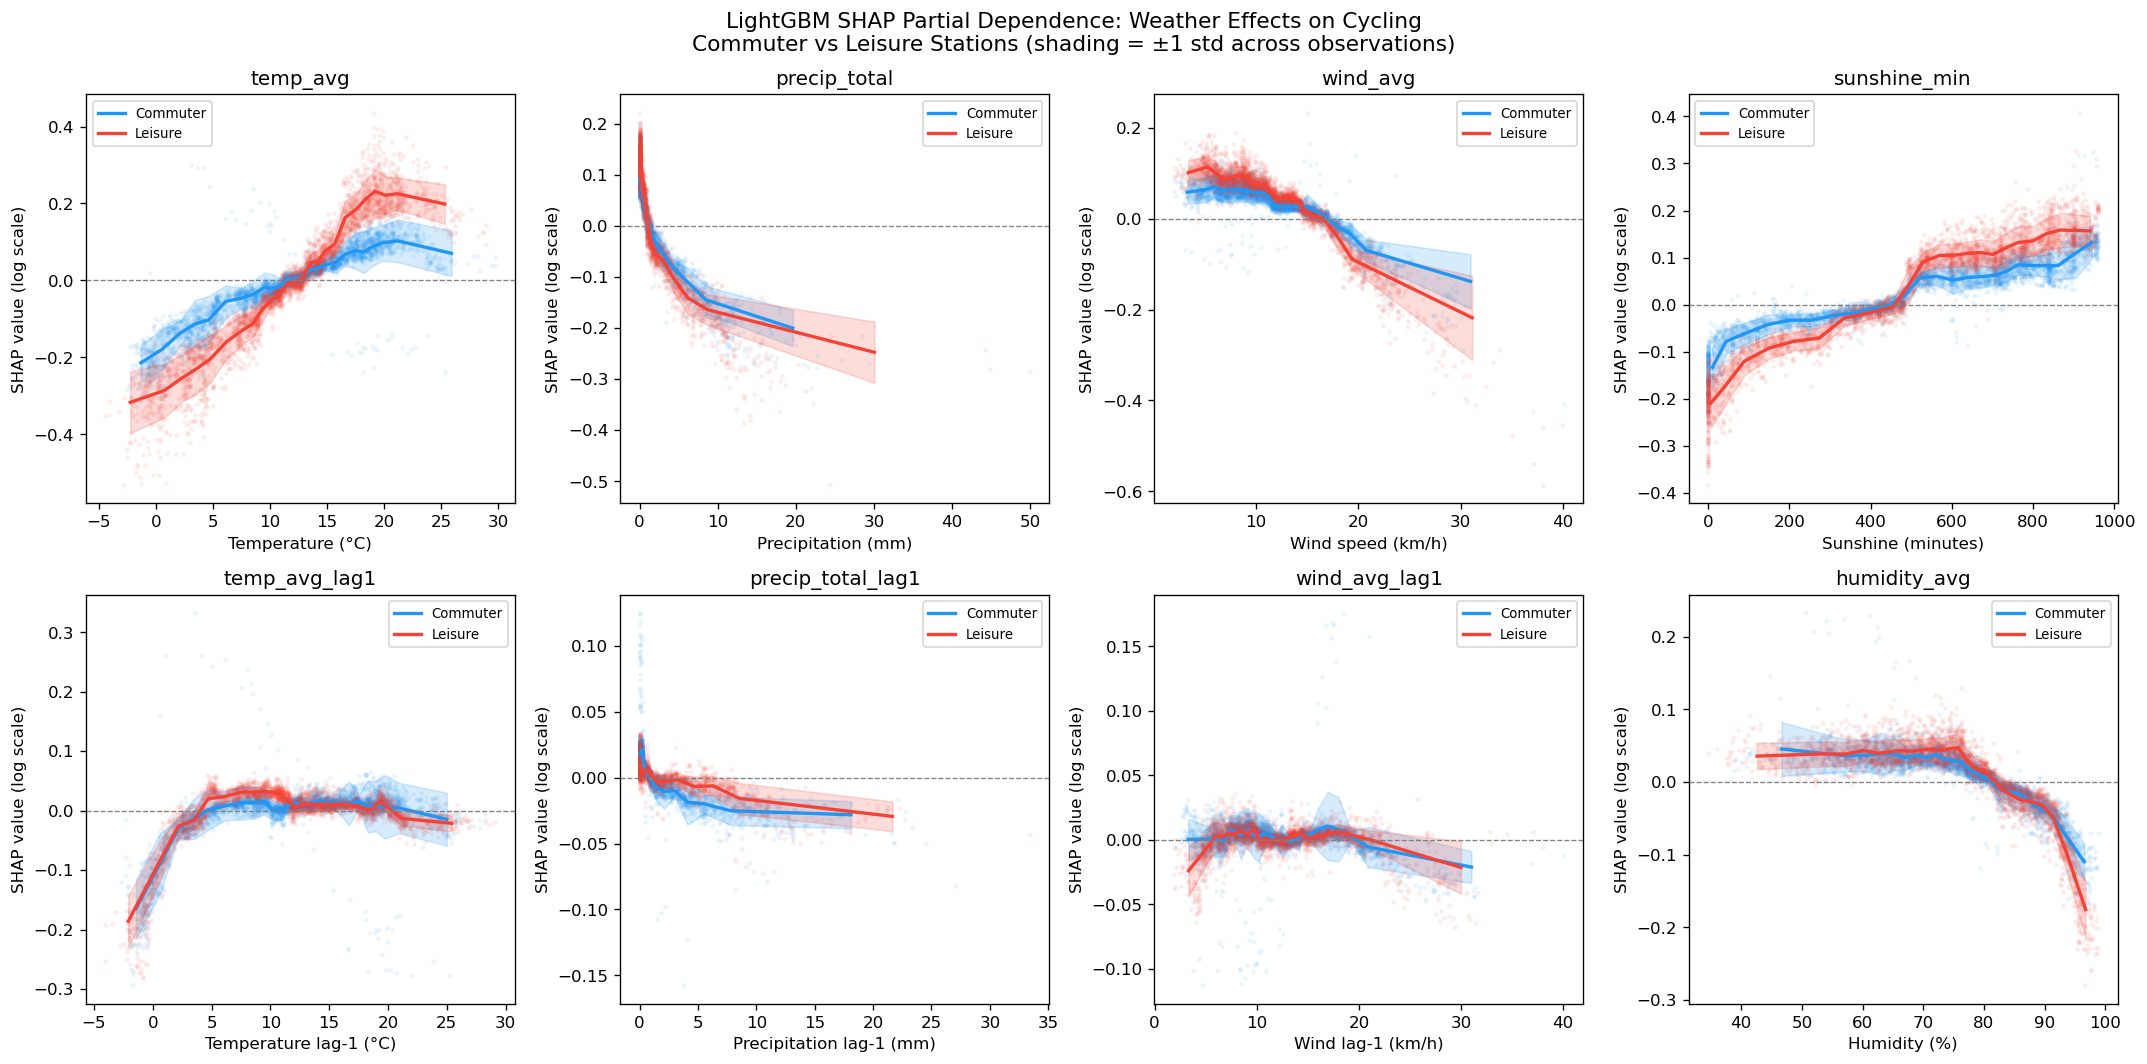

08b_lgb_shap_pdp.png saved.


In [136]:
def shap_smooth(x_vals, shap_vals, n_bins=25):
    """Bin x and return bin centres + mean ± std of SHAP values per bin."""
    bins = np.percentile(x_vals, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    centres, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x_vals >= lo) & (x_vals < hi)
        if mask.sum() < 3:
            continue
        centres.append((lo + hi) / 2)
        means.append(shap_vals[mask].mean())
        stds.append(shap_vals[mask].std())
    return np.array(centres), np.array(means), np.array(stds)

# 2×4 grid — same layout as notebook 08 fig20
weather_terms = [
    (0, "temp_avg",          "Temperature (°C)"),
    (1, "precip_total",      "Precipitation (mm)"),
    (2, "wind_avg",          "Wind speed (km/h)"),
    (3, "sunshine_min",      "Sunshine (minutes)"),
    (5, "temp_avg_lag1",     "Temperature lag-1 (°C)"),
    (6, "precip_total_lag1", "Precipitation lag-1 (mm)"),
    (7, "wind_avg_lag1",     "Wind lag-1 (km/h)"),
    (4, "humidity_avg",      "Humidity (%)"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (feat_idx, feat_name, xlabel) in zip(axes, weather_terms):
    x_c = X_test_c.iloc[idx_c_s, feat_idx].values
    x_l = X_test_l.iloc[idx_l_s, feat_idx].values
    s_c = shap_c[:, feat_idx]
    s_l = shap_l[:, feat_idx]

    ax.scatter(x_c, s_c, alpha=0.06, s=4, color=COLORS["commuter"])
    ax.scatter(x_l, s_l, alpha=0.06, s=4, color=COLORS["leisure"])

    for x_v, s_v, color, label in [
        (x_c, s_c, COLORS["commuter"], "Commuter"),
        (x_l, s_l, COLORS["leisure"],  "Leisure"),
    ]:
        cx, cm, cs = shap_smooth(x_v, s_v)
        ax.plot(cx, cm, color=color, linewidth=2, label=label)
        ax.fill_between(cx, cm - cs, cm + cs, alpha=0.18, color=color)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("SHAP value (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "LightGBM SHAP Partial Dependence: Weather Effects on Cycling\n"
    "Commuter vs Leisure Stations (shading = ±1 std across observations)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(FIGS / "08b_lgb_shap_pdp.png", dpi=150)
plt.show()
print("08b_lgb_shap_pdp.png saved.")


## 8. Weather-Normalized Cycling Index

Normalized cycling index saved.


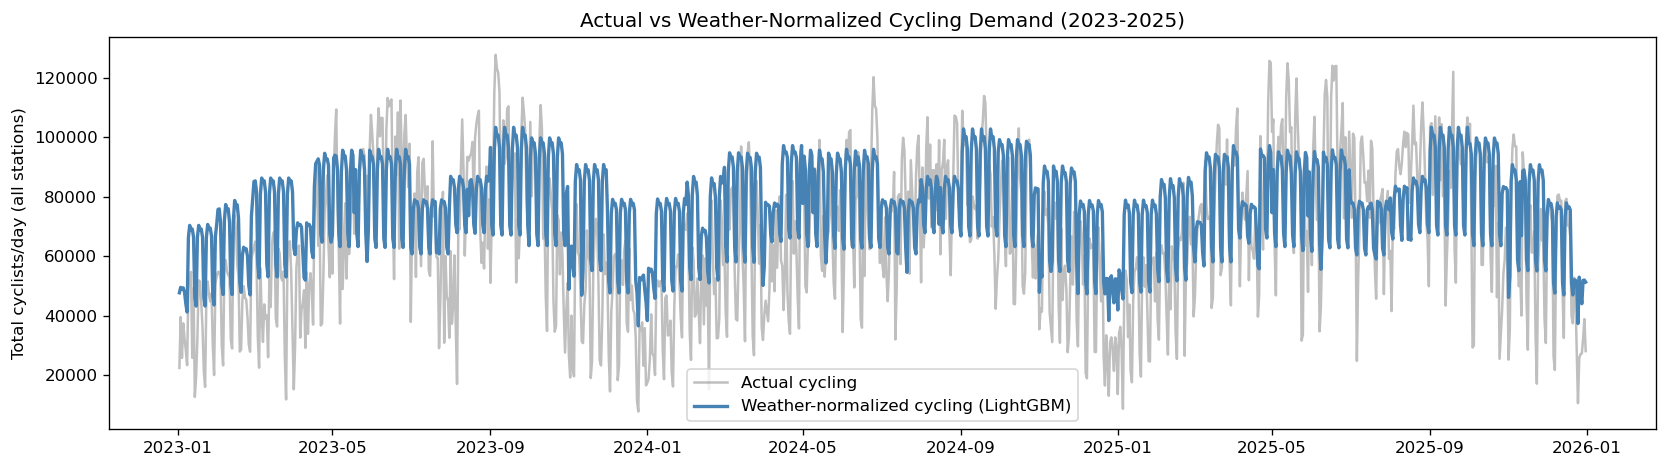

08b_normalized_vs_actual.png saved.


In [137]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
    "wind_avg_lag1"     : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

panel_norm_clean = panel_norm[ALL_FEATURES + ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]].dropna().copy()

# Build feature DataFrame with correct dtypes, then replace weather with reference values
X_norm = panel_norm_clean[ALL_FEATURES].copy()
for col in CAT_FEATURES:
    X_norm[col] = X_norm[col].astype("int32")
for feat, val_ref in ref_weather.items():
    X_norm[feat] = val_ref

panel_norm_clean["normalized_count"] = lgb_full.predict(X_norm)

panel_norm_clean[["site ID", "naam", "date", "aantal",
                   "normalized_count", "site_type",
                   "day_type", "season"]].to_parquet(
    PROCESSED / "normalized_cycling.parquet", index=False
)
print("Normalized cycling index saved.")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2, label="Weather-normalized cycling (LightGBM)")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023-2025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08b_normalized_vs_actual.png", dpi=150)
plt.show()
print("08b_normalized_vs_actual.png saved.")


**1. Weather is the primary driver of seasonal fluctuations**

The seasonal amplitude of the actual cycling curve (grey) is far larger than the normalized curve (blue). During winter months, actual counts fall substantially below normalized levels, indicating that the winter cycling drop is largely attributable to adverse weather conditions rather than a genuine collapse in underlying demand.

**2. Calendar effects are fully preserved after normalization**

The blue curve retains a clear high-frequency oscillation throughout the entire period, reflecting the day-of-week effect (weekend peaks vs. weekday troughs).

**3. No evident growth trend in baseline cycling demand across three years**

The normalized curve holds a broadly stable mid-range level from 2023 through 2025, with no sustained upward trend.


## 9. Weather Effect Magnitudes

In [138]:
def weather_effect(model, X_base, feature_idx, bad_val, ref_val):
    """Counterfactual AME: change one weather feature across all training rows,
    average the % change in predicted count."""
    feat_name = ALL_FEATURES[feature_idx]
    X_bad = X_base.copy()
    X_ref = X_base.copy()
    X_bad[feat_name] = bad_val
    X_ref[feat_name] = ref_val
    pred_bad = model.predict(X_bad)
    pred_ref = model.predict(X_ref)
    return np.nanmean((pred_bad - pred_ref) / np.where(pred_ref > 0, pred_ref, np.nan) * 100)

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0C vs 15C)",        0,  0.0,  15.0),
    ("Cool day (8C vs 15C)",        0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("=" * 65)
print("LGBM WEATHER EFFECT SIZES  (counterfactual AME, train 2023-2024)")
print("=" * 65)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8}")
print("-" * 65)
for label, feat_idx, bad_val, ref_val in comparisons:
    ef = weather_effect(lgb_full,     X_trainval,   feat_idx, bad_val, ref_val)
    ec = weather_effect(lgb_commuter, X_trainval_c, feat_idx, bad_val, ref_val)
    el = weather_effect(lgb_leisure,  X_trainval_l, feat_idx, bad_val, ref_val)
    print(f"{label:<35} | {ef:>6.1f}% | {ec:>8.1f}% | {el:>7.1f}%")
print("=" * 65)


LGBM WEATHER EFFECT SIZES  (counterfactual AME, train 2023-2024)
Condition                           |    Full |  Commuter |  Leisure
-----------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -26.9% |    -26.2% |   -31.6%
Light rain (2mm vs 0mm)             |  -12.9% |    -11.6% |   -16.8%
Cold day (0C vs 15C)                |  -24.6% |    -20.8% |   -31.4%
Cool day (8C vs 15C)                |  -13.9% |     -8.5% |   -21.0%
Strong wind (40 vs 10 km/h)         |  -34.7% |    -32.8% |   -38.2%
No sunshine (0 vs 300 min)          |  -11.8% |    -10.3% |   -13.8%


## 10. Save Models

In [139]:
models = {
    "lgbm_full"     : lgb_full,
    "lgbm_commuter" : lgb_commuter,
    "lgbm_leisure"  : lgb_leisure,
    "le_site"       : le_site,
    "le_commuter"   : le_c,
    "le_leisure"    : le_l,
    "model_type"    : "lightgbm_poisson",
    "ALL_FEATURES"  : ALL_FEATURES,
    "ref_weather"   : ref_weather,
}
with open(PROCESSED / "lgbm_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'lgbm_models.pkl'}")


Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/lgbm_models.pkl


## 11. Final Summary

In [140]:
heavy_rain_full = weather_effect(lgb_full, X_trainval, 1, 20.0,  0.0)
cold_day_full   = weather_effect(lgb_full, X_trainval, 0,  0.0, 15.0)
strong_wind_full= weather_effect(lgb_full, X_trainval, 2, 40.0, 10.0)

print("=" * 52)
print("LIGHTGBM MODELLING SUMMARY")
print("=" * 52)
print("Model-selection split:")
print(f"  Training period   : 2023       ({len(y_train):,} observations)")
print(f"  Validation period : 2024       ({len(y_val):,} observations)")
print()
print(f"Final training data : 2023-2024  ({len(y_trainval):,} observations)")
print(f"Final test period   : 2025       ({len(y_test):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full LightGBM     : MAE={test_mae:.1f}, R²={test_r2:.3f}")
print(f"  Commuter LightGBM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure LightGBM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print()
print("Key weather effects on cycling demand (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0C)     : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")



LIGHTGBM MODELLING SUMMARY
Model-selection split:
  Training period   : 2023       (47,709 observations)
  Validation period : 2024       (48,329 observations)

Final training data : 2023-2024  (96,038 observations)
Final test period   : 2025       (48,151 observations)

Model performance (test set):
  Full LightGBM     : MAE=110.8, R²=0.866
  Commuter LightGBM : MAE=104.3, R²=0.819
  Leisure LightGBM  : MAE=125.2, R²=0.787

Key weather effects on cycling demand (full model):
  Heavy rain (20mm) : -26.9%
  Cold day (0C)     : -24.6%
  Strong wind       : -34.7%
